# xLSTM — Fixed Implementation
Character-level language model on Tiny Shakespeare.

**Bugs fixed vs original:**
- sLSTM now recurs properly over timesteps (was applying to full tensor at once)
- `hidden_states` was always zeros — recurrent state now actually propagates
- mLSTM memory is now a proper `(B, D, D)` matrix updated with outer products
- Causal masking added to mLSTM attention
- Stabilizer in sLSTM uses `max(|n|, 1)` to prevent division issues


In [1]:
import os
import math
import time
import pickle
import subprocess
from contextlib import nullcontext
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F

%matplotlib inline
print('imports ok')

imports ok


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype  = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float32'
print(f'device: {device}  |  dtype: {dtype}')

device: cuda  |  dtype: bfloat16


## Data

In [3]:
data_dir = os.path.join('data', 'shakespeare_char')

if not os.path.exists(os.path.join(data_dir, 'train.bin')):
    print('Preparing shakespeare_char dataset...')
    subprocess.run(['python', 'prepare.py'], cwd=data_dir, check=True)
else:
    print('Dataset already prepared.')

meta_path = os.path.join(data_dir, 'meta.pkl')
with open(meta_path, 'rb') as f:
    meta = pickle.load(f)

stoi, itos = meta['stoi'], meta['itos']
vocab_size  = meta['vocab_size']
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print(f'Vocab size: {vocab_size}')
print(f'Characters: {repr("".join(itos[i] for i in range(vocab_size)))}')

Dataset already prepared.
Vocab size: 65
Characters: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


In [4]:
train_data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_data   = np.memmap(os.path.join(data_dir, 'val.bin'),   dtype=np.uint16, mode='r')

print(f'Train: {len(train_data):,} tokens')
print(f'Val:   {len(val_data):,} tokens')
print(f'\nSample:\n{decode(train_data[:200].tolist())}')

Train: 1,003,854 tokens
Val:   111,540 tokens

Sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [5]:
block_size = 64
batch_size = 64

def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x  = torch.stack([torch.from_numpy(data[i:i+block_size].astype(np.int64))   for i in ix])
    y  = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print(f'x: {xb.shape}  y: {yb.shape}')
print(f'Sample: "{decode(xb[0, :40].tolist())}"')

x: torch.Size([64, 64])  y: torch.Size([64, 64])
Sample: " number of his fair demands
Shall be acc"


## Model — Fixed xLSTM

### sLSTM
Scalar memory cell, recurs over time steps `t = 0 … T-1`.

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{z}_t, \quad n_t = f_t \odot n_{t-1} + i_t, \quad h_t = o_t \odot \tanh\!\left(\frac{c_t}{\max(|n_t|,1)}\right)$$

### mLSTM
Matrix memory `C` of shape `(B, D, D)`, updated with outer products:

$$C_t = f_t \odot C_{t-1} + i_t \cdot (v_t \otimes k_t), \quad n_t = f_t \odot n_{t-1} + i_t \odot k_t$$

$$h_t = o_t \odot \tanh\!\left(\frac{C_t \, q_t}{\max(|n_t^\top q_t|,1)}\right)$$

In [6]:
# ─────────────────────────────────────────────
#  Config
# ─────────────────────────────────────────────
@dataclass
class GPTConfig:
    block_size: int   = 256
    vocab_size: int   = 65
    n_layer:    int   = 6
    n_head:     int   = 6
    n_embd:     int   = 384
    dropout:    float = 0.2
    bias:       bool  = False


# ─────────────────────────────────────────────
#  sLSTM  (FIX: proper time-step recurrence)
# ─────────────────────────────────────────────
class sLSTM(nn.Module):
    """Scalar-memory LSTM that recurs over T timesteps."""

    def __init__(self, config):
        super().__init__()
        d = config.n_embd
        # Input projections for z, i, f, o  (4 gates)
        self.W = nn.Linear(d, 4 * d, bias=config.bias)
        # Recurrent projections (no bias — standard practice)
        self.U = nn.Linear(d, 4 * d, bias=False)
        self.o_proj = nn.Linear(d, d, bias=config.bias)
        self.ln     = nn.LayerNorm(d)

    def forward(self, x):
        """
        x : (B, T, D)
        returns (B, T, D)
        """
        B, T, D = x.shape

        h = x.new_zeros(B, D)   # hidden state
        c = x.new_zeros(B, D)   # cell state
        n = x.new_zeros(B, D)   # normalizer state

        outputs = []
        for t in range(T):
            xt     = x[:, t, :]                             # (B, D)
            gates  = self.W(xt) + self.U(h)                 # (B, 4D)
            z, i, f, o = gates.chunk(4, dim=-1)

            # Exponential gates (xLSTM paper eq. 3)
            i_gate = torch.exp(i)
            f_gate = torch.exp(f)

            c  = f_gate * c + i_gate * torch.tanh(z)       # cell update
            n  = f_gate * n + i_gate                        # normalizer update

            # Stabilize: divide by max(|n|, 1) element-wise
            h  = torch.sigmoid(o) * torch.tanh(c / torch.clamp(n.abs(), min=1.0))
            outputs.append(h.unsqueeze(1))

        out = torch.cat(outputs, dim=1)                    # (B, T, D)
        return self.o_proj(self.ln(out))


# ─────────────────────────────────────────────
#  mLSTM  (FIX: matrix memory + causal mask)
# ─────────────────────────────────────────────
class mLSTM(nn.Module):
    """Matrix-memory LSTM (parallelisable over T with causal scan)."""

    def __init__(self, config):
        super().__init__()
        d = config.n_embd
        self.W_q = nn.Linear(d, d, bias=config.bias)
        self.W_k = nn.Linear(d, d, bias=config.bias)
        self.W_v = nn.Linear(d, d, bias=config.bias)
        self.W_i = nn.Linear(d, d, bias=config.bias)   # input gate (exp)
        self.W_f = nn.Linear(d, d, bias=config.bias)   # forget gate (exp)
        self.W_o = nn.Linear(d, d, bias=config.bias)   # output gate (sigmoid)
        self.o_proj = nn.Linear(d, d, bias=config.bias)
        self.ln     = nn.LayerNorm(d)
        
    def forward(self, x):
        B, T, D = x.shape
        q     = self.W_q(x)
        k     = self.W_k(x) / math.sqrt(D)
        v     = self.W_v(x)
        i_pre = torch.exp(self.W_i(x))
        f_pre = torch.exp(self.W_f(x))
        o     = torch.sigmoid(self.W_o(x))

        C = x.new_zeros(B, D, D)
        n = x.new_zeros(B, D)
        outputs = []
        for t in range(T):
            outer = torch.bmm(v[:, t].unsqueeze(2), k[:, t].unsqueeze(1))
            C = f_pre[:, t].unsqueeze(2) * C + i_pre[:, t].unsqueeze(2) * outer
            n = f_pre[:, t] * n + i_pre[:, t] * k[:, t]
            h_t = torch.bmm(C, q[:, t].unsqueeze(2)).squeeze(2)
            denom = torch.clamp((n * q[:, t]).sum(-1, keepdim=True).abs(), min=1.0)
            outputs.append((o[:, t] * torch.tanh(h_t / denom)).unsqueeze(1))

        return self.o_proj(self.ln(torch.cat(outputs, dim=1)))


# ─────────────────────────────────────────────
#  MLP
# ─────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        d = config.n_embd
        self.net = nn.Sequential(
            nn.Linear(d, 4 * d, bias=config.bias),
            nn.GELU(),
            nn.Linear(4 * d, d, bias=config.bias),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


# ─────────────────────────────────────────────
#  xLSTM Block  (FIX: hidden_states removed)
# ─────────────────────────────────────────────
class xLSTMBlock(nn.Module):
    """
    Pre-LN xLSTM block:
      x → sLSTM → residual
      x → mLSTM → residual
      x → MLP   → residual
    """
    def __init__(self, config):
        super().__init__()
        self.ln_s  = nn.LayerNorm(config.n_embd)
        self.slstm = sLSTM(config)
        self.ln_m  = nn.LayerNorm(config.n_embd)
        self.mlstm = mLSTM(config)
        self.ln_ff = nn.LayerNorm(config.n_embd)
        self.mlp   = MLP(config)
        self.drop  = nn.Dropout(config.dropout)

    def forward(self, x):
        x = x + self.drop(self.slstm(self.ln_s(x)))
        x = x + self.drop(self.mlstm(self.ln_m(x)))
        x = x + self.drop(self.mlp(self.ln_ff(x)))
        return x


# ─────────────────────────────────────────────
#  Full GPT-style xLSTM Model
# ─────────────────────────────────────────────
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.embedding     = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_embedding = nn.Embedding(config.block_size, config.n_embd)
        self.drop          = nn.Dropout(config.dropout)
        self.blocks        = nn.ModuleList([xLSTMBlock(config) for _ in range(config.n_layer)])
        self.ln_f          = nn.LayerNorm(config.n_embd)
        self.lm_head       = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        self.apply(self._init_weights)
        # Scale residual projections (GPT-2 style)
        for pn, p in self.named_parameters():
            if pn.endswith('o_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

        print(f'Parameters: {self.get_num_params()/1e6:.2f}M')

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters())

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.config.block_size

        pos = torch.arange(T, device=idx.device).unsqueeze(0)   # (1, T)
        x   = self.drop(self.embedding(idx) + self.pos_embedding(pos))

        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss   = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1
            )
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss   = None

        return logits, loss

    def configure_optimizers(self, weight_decay, lr, betas, device_type):
        decay     = [p for n, p in self.named_parameters() if p.requires_grad and p.dim() >= 2]
        no_decay  = [p for n, p in self.named_parameters() if p.requires_grad and p.dim() <  2]
        groups    = [{'params': decay, 'weight_decay': weight_decay},
                     {'params': no_decay, 'weight_decay': 0.0}]
        use_fused = (device_type == 'cuda') and ('fused' in str(torch.optim.AdamW.__doc__ or ''))
        return torch.optim.AdamW(groups, lr=lr, betas=betas,
                                 **(dict(fused=True) if use_fused else {}))

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            idx_next = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx

## Instantiate Model

In [7]:
config = GPTConfig(
    block_size = block_size,
    vocab_size = vocab_size,
    n_layer    = 2,
    n_head     = 4,       # unused by xLSTM, kept for config compat
    n_embd     = 64,
    dropout    = 0.1,
    bias       = False,
)

model = GPT(config).to(device)
print(model)

Parameters: 0.21M
GPT(
  (embedding): Embedding(65, 64)
  (pos_embedding): Embedding(64, 64)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x xLSTMBlock(
      (ln_s): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (slstm): sLSTM(
        (W): Linear(in_features=64, out_features=256, bias=False)
        (U): Linear(in_features=64, out_features=256, bias=False)
        (o_proj): Linear(in_features=64, out_features=64, bias=False)
        (ln): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (ln_m): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mlstm): mLSTM(
        (W_q): Linear(in_features=64, out_features=64, bias=False)
        (W_k): Linear(in_features=64, out_features=64, bias=False)
        (W_v): Linear(in_features=64, out_features=64, bias=False)
        (W_i): Linear(in_features=64, out_features=64, bias=False)
        (W_f): Linear(in_features=64, out_features=64, bias=False)
        (W_o): Linear(in_f

## Training

/tmp/ipykernel_1238170/3399084109.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


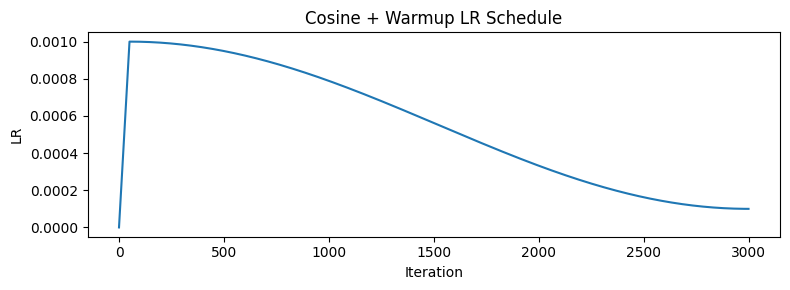

In [8]:
# ── Hyperparameters ───────────────────────────
learning_rate  = 1e-3
weight_decay   = 0.1
beta1, beta2   = 0.9, 0.99
grad_clip      = 1.0
max_iters      = 3000
warmup_iters   = 50
lr_decay_iters = 3000
min_lr         = 1e-4
eval_interval  = 250
eval_iters     = 250
log_interval   = 25

# ── Mixed precision ───────────────────────────
device_type = 'cuda' if 'cuda' in device else 'cpu'
ptdtype = {'float32': torch.float32,
           'bfloat16': torch.bfloat16,
           'float16':  torch.float16}[dtype]
ctx    = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)


def get_lr(it):
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    if it > lr_decay_iters:
        return min_lr
    t = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    return min_lr + 0.5 * (1.0 + math.cos(math.pi * t)) * (learning_rate - min_lr)


@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with ctx:
                _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

# Visualise LR schedule
plt.figure(figsize=(8, 3))
plt.plot([get_lr(i) for i in range(max_iters)])
plt.xlabel('Iteration'); plt.ylabel('LR'); plt.title('Cosine + Warmup LR Schedule')
plt.tight_layout(); plt.show()

In [9]:
torch.manual_seed(1337)

train_losses, val_losses, eval_iters_list = [], [], []
best_val_loss = 1e9
t0 = time.time()

for iter_num in range(max_iters + 1):
    # LR update
    lr = get_lr(iter_num)
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    # Eval
    if iter_num % eval_interval == 0:
        losses = estimate_loss()
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        eval_iters_list.append(iter_num)
        marker = ' *' if losses['val'] < best_val_loss else ''
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
        print(f"step {iter_num:5d} | train {losses['train']:.4f} | val {losses['val']:.4f} | lr {lr:.2e}{marker}")

    # Forward
    X, Y = get_batch('train')
    with ctx:
        logits, loss = model(X, Y)

    # Backward
    scaler.scale(loss).backward()
    if grad_clip != 0.0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    scaler.step(optimizer)
    scaler.update()
    optimizer.zero_grad(set_to_none=True)

    if iter_num % log_interval == 0 and iter_num > 0 and iter_num % eval_interval != 0:
        print(f"step {iter_num:5d} | loss {loss.item():.4f} | {(time.time()-t0)*1000:.0f}ms")
    t0 = time.time()

print(f'\nDone. Best val loss: {best_val_loss:.4f}')

step     0 | train 4.1453 | val 4.1478 | lr 0.00e+00 *
step    25 | loss 3.7126 | 456ms
step    50 | loss 3.3091 | 462ms
step    75 | loss 3.1006 | 460ms
step   100 | loss 2.7982 | 463ms
step   125 | loss 2.6275 | 458ms
step   150 | loss 2.4720 | 463ms
step   175 | loss 2.4494 | 465ms
step   200 | loss 2.3665 | 476ms
step   225 | loss 2.2967 | 460ms
step   250 | train 2.2211 | val 2.2290 | lr 9.90e-04 *
step   275 | loss 2.2155 | 459ms
step   300 | loss 2.2021 | 457ms
step   325 | loss 2.2018 | 457ms
step   350 | loss 2.0748 | 457ms
step   375 | loss 2.1158 | 458ms
step   400 | loss 2.1143 | 469ms
step   425 | loss 2.0556 | 457ms
step   450 | loss 1.9893 | 458ms
step   475 | loss 1.9920 | 458ms
step   500 | train 1.9582 | val 2.0179 | lr 9.49e-04 *
step   525 | loss 1.9767 | 457ms
step   550 | loss 1.9735 | 459ms
step   575 | loss 1.9503 | 457ms
step   600 | loss 1.9360 | 460ms
step   625 | loss 1.9173 | 493ms
step   650 | loss 1.8522 | 456ms
step   675 | loss 1.9239 | 457ms
step   700

KeyboardInterrupt: 

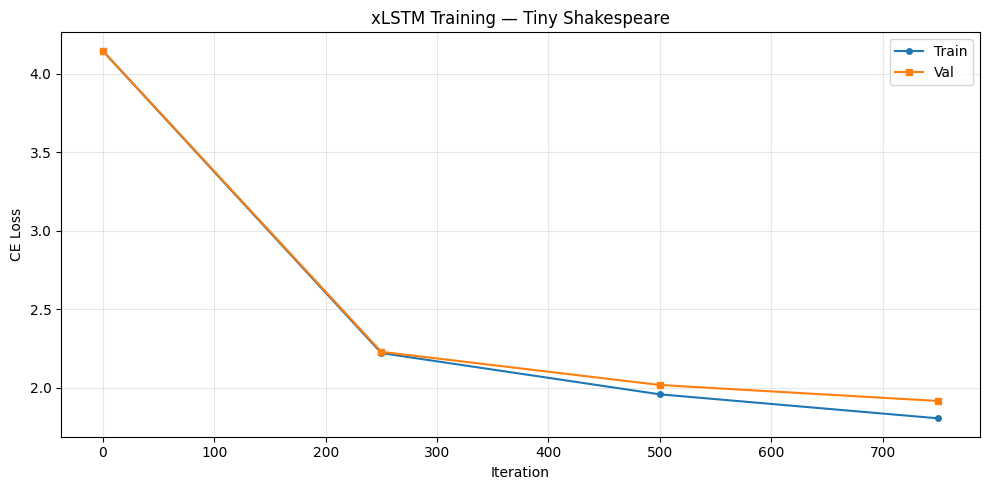

Final train: nan  |  val: nan


In [10]:
plt.figure(figsize=(10, 5))
plt.plot(eval_iters_list, train_losses, label='Train', marker='o', markersize=4)
plt.plot(eval_iters_list, val_losses,   label='Val',   marker='s', markersize=4)
plt.xlabel('Iteration'); plt.ylabel('CE Loss')
plt.title('xLSTM Training — Tiny Shakespeare')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f'Final train: {train_losses[-1]:.4f}  |  val: {val_losses[-1]:.4f}')

## Text Generation

In [11]:
def generate_text(prompt='ROMEO:', max_new_tokens=500, temperature=0.8, top_k=200):
    model.eval()
    x = torch.tensor(encode(prompt), dtype=torch.long, device=device)[None, ...]
    with torch.no_grad():
        with ctx:
            y = model.generate(x, max_new_tokens, temperature=temperature, top_k=top_k)
    model.train()
    return decode(y[0].tolist())

In [12]:
print(generate_text('ROMEO:', max_new_tokens=1000, temperature=0.8))

/pytorch/aten/src/ATen/native/cuda/TensorCompare.cu:109: _assert_async_cuda_kernel: block: [0,0,0], thread: [0,0,0] Assertion `probability tensor contains either `inf`, `nan` or element < 0` failed.


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
print(generate_text('KING HENRY:', max_new_tokens=1000, temperature=0.5))

In [ ]:
print(generate_text('First Citizen:\n', max_new_tokens=1000, temperature=1.0))

## Save Checkpoint

In [ ]:
out_dir = 'out-xlstm-shakespeare-char'
os.makedirs(out_dir, exist_ok=True)

torch.save({
    'model':      model.state_dict(),
    'model_args': dict(block_size=block_size, vocab_size=vocab_size,
                       n_layer=config.n_layer, n_head=config.n_head,
                       n_embd=config.n_embd, dropout=config.dropout, bias=config.bias),
    'best_val_loss': best_val_loss,
}, os.path.join(out_dir, 'ckpt.pt'))

print(f'Saved to {out_dir}/ckpt.pt')